# Data

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [7]:
#getting data
import requests
def get_sp500_tickers():  #getting index constituents
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'  #use wikipedia to get them
    headers = { 'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    tables = pd.read_html(response.text)
    sp500_table = tables[0]
    tickers = sp500_table['Symbol'].tolist()
    tickers = [t.replace('.', '-') for t in tickers]
    print(f'Found {len(tickers)} tickers')
    return tickers
tickers = get_sp500_tickers()
print(tickers[:10])

Found 503 tickers
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [8]:
def download_data(tickers, start="1999-10-11", end="2023-03-08", index_ticker='^GSPC', batch_size=50):
    all_prices = {}
    #Downloading Index Data
    print(f'Downloading Index {index_ticker}...')
    index_data = yf.download(index_ticker, start=start, end=end, auto_adjust=True, progress=False)
    all_prices[index_ticker] = index_data['Close'].squeeze()
    
    #Downloadinng Constituents Data
    n_batches = len(tickers) // batch_size + 1
    failed = []
    for i in range(n_batches):
        current_batch = tickers[i*batch_size : (i+1)*batch_size]
        if not current_batch:
            continue
        print(f"Batch {i+1}/{n_batches}: downloading {len(current_batch)} tickers...")
        try:
            data = yf.download(current_batch, start=start, end=end, auto_adjust=True, progress=False)
            if isinstance(data.columns, pd.MultiIndex):
                close_data = data['Close']
            else:
                close_data = data[['Close']]
                close_data.columns = current_batch
            for ticker in current_batch:
                if ticker in close_data.columns:
                    all_prices[ticker] = close_data[ticker].squeeze()
                else:
                    failed.append(ticker)
        except Function as e:
            print(f' Batch {i+1} failed: {e}') 
            failed.extend(current_batch)
    print(f'\nFailed to download: {len(failed)} tickers')
    print(f'Succesfully downloaded: {len(all_prices) -1} stocks + index')
    prices_df = pd.DataFrame(all_prices)
    return prices_df, failed

prices_df, failed = download_data(tickers)
print(f"\nShape: {prices_df.shape}")
print(f"Date range: {prices_df.index[0]} to {prices_df.index[-1]}")

Batch 1/11: downloading 50 tickers...
Batch 2/11: downloading 50 tickers...
Batch 3/11: downloading 50 tickers...
Batch 4/11: downloading 50 tickers...
Batch 5/11: downloading 50 tickers...



1 Failed download:
['GEV']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 6/11: downloading 50 tickers...



1 Failed download:
['KVUE']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 7/11: downloading 50 tickers...
Batch 8/11: downloading 50 tickers...


...

Batch 9/11: downloading 50 tickers...



2 Failed downloads:
['SOLV', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 10/11: downloading 50 tickers...



1 Failed download:
['VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 11/11: downloading 3 tickers...

Failed to download: 0 tickers
Succesfully downloaded: 503 stocks + index

Shape: (5889, 504)
Date range: 1999-10-11 00:00:00 to 2023-03-07 00:00:00


In [9]:
#Save the data
save_path = r"C:/Users/chira/OneDrive/Desktop"
index_col = '^GSPC'
index_prices = prices_df[[index_col]]
stock_prices = prices_df.drop(columns=[index_col])

#Save to Excel
index_prices.to_excel(f"{save_path}/index_prices.xlsx")
stock_prices.to_excel(f"{save_path}/stock_prices.xlsx")
print("Files saved successfully!")

Files saved successfully!


### Data

In [10]:
# Print index head
print("\nS&P 500:")
print(prices_df[['^GSPC']].head())

# Print stocks head 
print("\nStocks:")
print(prices_df.drop(columns=['^GSPC']).head())


S&P 500:
                  ^GSPC
Date                   
1999-10-11  1335.209961
1999-10-12  1313.040039
1999-10-13  1285.550049
1999-10-14  1283.420044
1999-10-15  1247.410034

Stocks:
                  MMM       AOS       ABT  ABBV  ACN       ADBE      AMD  \
Date                                                                       
1999-10-11  19.277573  3.117105  9.481837   NaN  NaN  14.888317  9.50000   
1999-10-12  18.744915  3.027126  9.253014   NaN  NaN  14.647935  9.37500   
1999-10-13  18.427847  2.969285  8.889950   NaN  NaN  14.516108  9.12500   
1999-10-14  18.643459  2.943576  8.818140   NaN  NaN  14.663443  9.00000   
1999-10-15  18.136141  2.956431  8.631433   NaN  NaN  14.562634  8.78125   

                  AES       AFL   A  ...        WMB  WTW  WDAY  WYNN  \
Date                                 ...                               
1999-10-11  17.711998  6.642323 NaN  ...  10.380813  NaN   NaN   NaN   
1999-10-12  17.239161  6.679327 NaN  ...  10.730923  NaN   NaN  

### Data Split

In [11]:
#Splitting
period1_start = "1999-10-11"
period1_end   = "2018-10-10"
#Panel II period: 01 Jan 2018 to 08 Mar 2023
period2_start = "2018-01-01"
period2_end   = "2023-03-08"
#Slicing the period
prices_p1 = prices_df.loc[period1_start:period1_end].copy()
prices_p2 = prices_df.loc[period2_start:period2_end].copy()

print("Period 1 prices shape:", prices_p1.shape)
print("Period 2 prices shape:", prices_p2.shape)

Period 1 prices shape: (4782, 504)
Period 2 prices shape: (1303, 504)


In [12]:
#Cleaning
#Keep index column
index_col = "^GSPC"
#Clean Panel 1
prices_p1 = prices_p1.dropna(subset=[index_col])
prices_p1 = prices_p1.dropna(axis=1)

#Clean Panel 2
prices_p2 = prices_p2.dropna(subset=[index_col])
prices_p2 = prices_p2.dropna(axis=1)

print("\nAfter cleaning:")
print("Panel 1:")
print(prices_p1.index.min(), "to", prices_p1.index.max())
print("Stocks:", prices_p1.shape[1] - 1)

print("\nPanel 2:")
print(prices_p2.index.min(), "to", prices_p2.index.max())
print("Stocks:", prices_p2.shape[1] - 1)


After cleaning:
Panel 1:
1999-10-11 00:00:00 to 2018-10-10 00:00:00
Stocks: 344

Panel 2:
2018-01-02 00:00:00 to 2023-03-07 00:00:00
Stocks: 477


### Returns

In [13]:
returns_p1 = prices_p1.pct_change().dropna()
returns_p2 = prices_p2.pct_change().dropna()

In [14]:
#Separating index and constituents
index_col = "^GSPC"

stock_returns_p1 = returns_p1.drop(columns=[index_col])
index_returns_p1 = returns_p1[index_col]
stock_returns_p2 = returns_p2.drop(columns=[index_col])
index_returns_p2 = returns_p2[index_col]

print("Panel 1 stocks:", stock_returns_p1.shape)
print("Panel 1 index:", index_returns_p1.shape)

print("Panel 2 stocks:", stock_returns_p2.shape)
print("Panel 2 index:", index_returns_p2.shape)

Panel 1 stocks: (4781, 344)
Panel 1 index: (4781,)
Panel 2 stocks: (1302, 477)
Panel 2 index: (1302,)


### Rolling Windows

In [15]:
def create_windows(stock_returns, index_returns, insample=504, oos=21, step=21):
    windows = []
    n_obs = len(stock_returns)

    for start in range(0, n_obs - insample - oos + 1, step):

        end_in = start + insample
        end_oos = end_in + oos

        window = {
            "R_in": stock_returns.iloc[start:end_in],
            "R0_in": index_returns.iloc[start:end_in],
            "R_oos": stock_returns.iloc[end_in:end_oos],
            "R0_oos": index_returns.iloc[end_in:end_oos],
            "train_start": stock_returns.index[start],
            "train_end": stock_returns.index[end_in - 1],
            "oos_start": stock_returns.index[end_in],
            "oos_end": stock_returns.index[end_oos - 1]}
        windows.append(window)

    print("Number of windows:", len(windows))
    return windows
windows_p1 = create_windows(stock_returns_p1, index_returns_p1)
windows_p2 = create_windows(stock_returns_p2, index_returns_p2)

Number of windows: 203
Number of windows: 38


### Taken's Embedding

In [16]:
def takens_embed(return_series, d=3, tau=1): #converts the return data into a point cloud and tau parameter allows non-consecutive lags
    T = len(return_series)
    n_points = T - (d - 1) * tau  #d is the embedding dimension, 3 as per the paper, tau is the time delay between dimensions, 1 as per the paper
    
    if n_points <= 0:
        raise ValueError(f"Series too short for Takens embedding")
    #the embedding matrix, where column k contains the series shifted by k*tau
    X = np.column_stack([
        return_series[k*tau : k*tau + n_points]
        for k in range(d)])
    return X
#sanity check
test_series = np.array([0.01, -0.02, 0.005, 0.03, -0.01, 0.008, -0.015])  #random numbers to check if Taken has been applied proper
embedded = takens_embed(test_series, d=3, tau=1)
print("Input series:", test_series)
print("Embedded shape:", embedded.shape)  # should be (5, 3)
print("First 3 points:")
print(embedded[:3])

Input series: [ 0.01  -0.02   0.005  0.03  -0.01   0.008 -0.015]
Embedded shape: (5, 3)
First 3 points:
[[ 0.01  -0.02   0.005]
 [-0.02   0.005  0.03 ]
 [ 0.005  0.03  -0.01 ]]


### Overlapping Sub-Series

In [17]:
#Creating overlapping sub-series
def get_subseries(return_series, T_tilde=42, h=21):
   T = len(return_series)
   n_sub = (T - T_tilde) // h + 1
   subseries = []
   for j in range(n_sub):
        start = j * h
        end   = start + T_tilde
        subseries.append(return_series[start:end])
   return subseries 
#Check
dummy = np.random.randn(504)
subs = get_subseries(dummy, T_tilde=42, h=21)
print(f"504-day window → {len(subs)} sub-series of length {len(subs[0])}")

504-day window → 23 sub-series of length 42


### Persistent Homology

In [18]:
#Computing persistent homology of a point cloud
import ripser
def compute_persistence_diagrams(point_cloud, max_dim=1):
    result = ripser.ripser(point_cloud, maxdim=max_dim)
    dgm0 = result['dgms'][0]  # H0: connected components
    dgm1 = result['dgms'][1]  # H1: loops
    dgm0 = dgm0[np.isfinite(dgm0[:, 1])]
    dgm1 = dgm1[np.isfinite(dgm1[:, 1])]
    return dgm0, dgm1

In [19]:
# Persistence landscape and L1 norm
def compute_landscape_function(diagram, t_grid):
    if len(diagram) == 0:
        return np.zeros(len(t_grid))

    births = diagram[:, 0]
    deaths = diagram[:, 1]

    tent_values = np.maximum(
        0,
        np.minimum(
            t_grid[:, None] - births[None, :],
            deaths[None, :] - t_grid[:, None]))
    return tent_values.max(axis=1)

def compute_tda_norms_for_stock(stock_returns, T_tilde=42, h=21, d=3, tau=1, n_grid=500):
    subseries_list = get_subseries(stock_returns, T_tilde=T_tilde, h=h)

    all_dgm0 = []
    all_dgm1 = []

    for sub in subseries_list:
        cloud = takens_embed(sub, d=d, tau=tau)
        dgm0, dgm1 = compute_persistence_diagrams(cloud)

        all_dgm0.append(dgm0)
        all_dgm1.append(dgm1)

    def global_grid(diagrams):
        valid = [d.ravel() for d in diagrams if len(d) > 0]

        if len(valid) == 0:
            return np.linspace(0, 1, n_grid), 1 / (n_grid - 1)

        vals = np.concatenate(valid)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            return np.linspace(0, 1, n_grid), 1 / (n_grid - 1)

        t_min = vals.min()
        t_max = vals.max()

        if t_max <= t_min:
            return np.linspace(0, 1, n_grid), 1 / (n_grid - 1)

        grid = np.linspace(t_min, t_max, n_grid)
        dt = (t_max - t_min) / (n_grid - 1)

        return grid, dt

    t0, dt0 = global_grid(all_dgm0)
    t1, dt1 = global_grid(all_dgm1)

    landscapes_h0 = np.array([
        compute_landscape_function(dgm, t0)
        for dgm in all_dgm0])

    landscapes_h1 = np.array([
        compute_landscape_function(dgm, t1)
        for dgm in all_dgm1])

    mean_landscape_h0 = landscapes_h0.mean(axis=0)
    mean_landscape_h1 = landscapes_h1.mean(axis=0)
    alpha_i = np.trapz(mean_landscape_h0, dx=dt0)
    beta_i = np.trapz(mean_landscape_h1, dx=dt1)

    return alpha_i, beta_i

### Alpha and Beta i's values

In [20]:
#All stocks in one window
from tqdm import tqdm

def compute_tda_norms_for_window(R_in):
    alphas = []
    betas = []

    for stock in tqdm(R_in.columns, desc="Computing TDA norms"):
        r_i = R_in[stock].values

        alpha_i, beta_i = compute_tda_norms_for_stock(r_i)

        alphas.append(alpha_i)
        betas.append(beta_i)

    alpha = np.array(alphas)
    beta = np.array(betas)

    return alpha, beta

### Optimisation

In [21]:
import cvxpy as cp

def optimise_tda_portfolio(R_in, R0_in, alpha, beta, model="EN11"):
    R = R_in.values
    R0 = R0_in.values
    T, n = R.shape

    alpha = np.asarray(alpha, dtype=float)
    beta = np.asarray(beta, dtype=float)

    if model == "EN11":
        alpha_use = alpha.copy()
        beta_use = alpha.copy()
    elif model == "EN12":
        alpha_use = alpha.copy()
        beta_use  = beta.copy()           #raw beta
    elif model == "Lasso":
        alpha_use = alpha.copy()
        beta_use  = np.zeros(n)           #no L2 term
    elif model == "TE":
        alpha_use = np.zeros(n)           #no penalty
        beta_use  = np.zeros(n)
    else:
        raise ValueError(f"Unknown model: {model}")

    w = cp.Variable(n)
    #tracking error
    tracking_error = cp.sum_squares(R @ w - R0)

    #Penalties
    l1_penalty = cp.sum(cp.multiply(alpha_use, cp.abs(w)))
    l2_penalty = 0.5*cp.sum(cp.multiply(beta_use**2, cp.square(w)))

    objective = cp.Minimize(tracking_error + l1_penalty + l2_penalty)

#Constraints
    constraints = [cp.sum(w) == 1,]
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL)
    if w.value is None:
        weights = np.ones(n) / n
    else:
        weights = w.value.copy()

    weights[np.abs(weights) < 1e-8] = 0

    if weights.sum() != 0:
        weights = weights / weights.sum()

    return weights

### Rolling BackTest

In [22]:
def rolling_backtest(windows, model="EN11"):
    all_oos_returns = []
    all_index_returns = []
    all_weights = []
    selected_assets = []

    for k, window in enumerate(windows):

        print(f"\nWindow {k+1}/{len(windows)} "
        f"Train: {window['train_start'].date()} to {window['train_end'].date()} "
        f"OOS:   {window['oos_start'].date()} to {window['oos_end'].date()}")

        R_in = window["R_in"]
        R0_in = window["R0_in"]
        R_oos = window["R_oos"]
        R0_oos = window["R0_oos"]

        #Computing TDA penalties
        if model == "TE":
            alpha = np.zeros(R_in.shape[1])
            beta  = np.zeros(R_in.shape[1])
        else:
            alpha, beta = compute_tda_norms_for_window(R_in)
            print(f"  alpha mean: {alpha.mean():.6f}   beta mean: {beta.mean():.6f}")

        #Solving optimisation
        weights = optimise_tda_portfolio(R_in, R0_in, alpha, beta, model=model)
        #Applying weights OOS
        portfolio_oos = R_oos.values @ weights

        all_oos_returns.append(pd.Series(portfolio_oos, index=R_oos.index))
        all_index_returns.append(R0_oos)
        all_weights.append(pd.Series(weights, index=R_in.columns))
        selected_assets.append(int(np.sum(np.abs(weights) > 1e-8)))

        print("Selected assets:", selected_assets[-1])

    results = pd.DataFrame({
        "portfolio": pd.concat(all_oos_returns),
        "index": pd.concat(all_index_returns)})

    weights_df = pd.DataFrame(all_weights)

    return results, weights_df, selected_assets

### Loops

In [23]:
#Run all models for both periods
models_to_run = ["TE", "Lasso", "EN11", "EN12"]

results_p1_all  = {}
weights_p1_all  = {}
selected_p1_all = {}

results_p2_all  = {}
weights_p2_all  = {}
selected_p2_all = {}

for model in models_to_run:
    print(f"\n{'='*60}")
    print(f"Running {model} — Period 1")
    print('='*60)
    res, wts, sel = rolling_backtest(windows_p1, model=model)
    results_p1_all[model]  = res
    weights_p1_all[model]  = wts
    selected_p1_all[model] = sel

    print(f"\n{'='*60}")
    print(f"Running {model} — Period 2")
    print('='*60)
    res, wts, sel = rolling_backtest(windows_p2, model=model)
    results_p2_all[model]  = res
    weights_p2_all[model]  = wts
    selected_p2_all[model] = sel


Running TE — Period 1

Window 1/203 Train: 1999-10-12 to 2001-10-15 OOS:   2001-10-16 to 2001-11-13
Selected assets: 344

Window 2/203 Train: 1999-11-10 to 2001-11-13 OOS:   2001-11-14 to 2001-12-13
Selected assets: 344

Window 3/203 Train: 1999-12-10 to 2001-12-13 OOS:   2001-12-14 to 2002-01-15
Selected assets: 344

Window 4/203 Train: 2000-01-11 to 2002-01-15 OOS:   2002-01-16 to 2002-02-14
Selected assets: 344

Window 5/203 Train: 2000-02-10 to 2002-02-14 OOS:   2002-02-15 to 2002-03-18
Selected assets: 344

Window 6/203 Train: 2000-03-13 to 2002-03-18 OOS:   2002-03-19 to 2002-04-17
Selected assets: 344

Window 7/203 Train: 2000-04-11 to 2002-04-17 OOS:   2002-04-18 to 2002-05-16
Selected assets: 344

Window 8/203 Train: 2000-05-11 to 2002-05-16 OOS:   2002-05-17 to 2002-06-17
Selected assets: 344

Window 9/203 Train: 2000-06-12 to 2002-06-17 OOS:   2002-06-18 to 2002-07-17
Selected assets: 344

Window 10/203 Train: 2000-07-12 to 2002-07-17 OOS:   2002-07-18 to 2002-08-15
Selecte

Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 344/344 [00:15<00:00, 22.33it/s]


  alpha mean: 0.001609   beta mean: 0.000052
Selected assets: 218

Window 2/203 Train: 1999-11-10 to 2001-11-13 OOS:   2001-11-14 to 2001-12-13


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 344/344 [00:15<00:00, 22.78it/s]


  alpha mean: 0.001640   beta mean: 0.000053
Selected assets: 239

Window 3/203 Train: 1999-12-10 to 2001-12-13 OOS:   2001-12-14 to 2002-01-15


...

  alpha mean: 0.000567   beta mean: 0.000022
Selected assets: 227

Window 37/38 Train: 2021-01-05 to 2023-01-04 OOS:   2023-01-05 to 2023-02-03


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 477/477 [00:22<00:00, 21.40it/s]


  alpha mean: 0.000586   beta mean: 0.000022
Selected assets: 231

Window 38/38 Train: 2021-02-04 to 2023-02-03 OOS:   2023-02-06 to 2023-03-07


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 477/477 [00:22<00:00, 21.47it/s]


  alpha mean: 0.000585   beta mean: 0.000022
Selected assets: 227


### Metrics

In [24]:
def compute_metrics(results_df, weights_df):
    r_p   = results_df['portfolio']
    r_m   = results_df['index']
    excess = r_p - r_m

    #Tracking performance
    te   = np.sqrt(np.mean((r_p - r_m) ** 2))
    corr = r_p.corr(r_m)

    #Risk measures
    vol = r_p.std() * np.sqrt(252)

    # Downside Deviation, average squared underperformance relative to the index
    shortfall = np.maximum(r_m.values - r_p.values, 0)
    dd        = np.sqrt(np.mean(shortfall ** 2))

    #VaR and CVaR at 95% confidence 
    var_level = np.percentile(r_p, 5)
    VaR  = -var_level
    CVaR = -r_p[r_p <= var_level].mean()

    #Risk-adjusted performance
    ann_return = r_p.mean() * 252
    sharpe = ann_return / vol if vol > 0 else 0.0

    sigma_e = excess.std() * np.sqrt(252)
    emr     = excess.mean() * 252
    ir      = emr / sigma_e if sigma_e > 0 else 0.0

    #Turnover Ratio
    w_arr = weights_df.fillna(0).values
    if len(w_arr) > 1:
        tr = np.mean(np.sum(np.abs(np.diff(w_arr, axis=0)), axis=1))
    else:
        tr = 0.0

    #Average selected assets
    n_assets = np.mean((np.abs(w_arr) > 1e-8).sum(axis=1))

    return {
        "TError":      te,
        "Correlation": corr,
        "Volatility":  vol,
        "DD":          dd,
        "VaR":         VaR,
        "CVaR":        CVaR,
        "SHR":         sharpe,
        "IR":          ir,
        "TR":          tr,
        "# Assets":    n_assets}

In [25]:
def build_table(results_all, weights_all, selected_all):
    rows = []
    for model in results_all:
        m = compute_metrics(results_all[model], weights_all[model])
        m["Model"] = model
        rows.append(m)
    df = pd.DataFrame(rows).set_index("Model")
    col_order = ["TError","Correlation","Volatility","DD","VaR","CVaR","SHR","IR","TR","# Assets"]
    return df[col_order]

print("\n=== Period 1 (1999–2018) ===")
table_p1 = build_table(results_p1_all, weights_p1_all, selected_p1_all)
display(table_p1.applymap(lambda x: f"{x:.4e}" if isinstance(x, float) and abs(x) < 0.01 else round(x, 4)))

print("\n=== Period 2 (2018–2023) ===")
table_p2 = build_table(results_p2_all, weights_p2_all, selected_p2_all)
display(table_p2.applymap(lambda x: f"{x:.4e}" if isinstance(x, float) and abs(x) < 0.01 else round(x, 4)))


=== Period 1 (1999–2018) ===


,TError,Correlation,Volatility,DD,VaR,CVaR,SHR,IR,TR,# Assets
Model,,,,,,,,,,
TE,1.7422e-03,0.9902,0.1939,1.0832e-03,0.0179,0.0292,0.5952,1.4303,0.8057,344.0000
Lasso,1.2801e-03,0.9945,0.1910,7.3461e-04,0.0179,0.0288,0.6077,1.9883,0.2619,229.5665
EN11,1.2801e-03,0.9945,0.1910,7.3461e-04,0.0179,0.0288,0.6077,1.9883,0.2619,229.5665
EN12,1.2801e-03,0.9945,0.1910,7.3461e-04,0.0179,0.0288,0.6077,1.9883,0.2619,229.5665



=== Period 2 (2018–2023) ===


,TError,Correlation,Volatility,DD,VaR,CVaR,SHR,IR,TR,# Assets
Model,,,,,,,,,,
TE,3.6565e-03,0.9749,0.2605,2.5038e-03,0.0235,0.0392,0.4026,0.1272,5.2327,477.0000
Lasso,1.3860e-03,0.9964,0.2550,8.5016e-04,0.0232,0.0389,0.4898,1.2470,0.2867,221.9211
EN11,1.3860e-03,0.9964,0.2550,8.5016e-04,0.0232,0.0389,0.4898,1.2470,0.2867,221.9211
EN12,1.3860e-03,0.9964,0.2550,8.5016e-04,0.0232,0.0389,0.4898,1.2470,0.2867,221.9211


### Growth of $1

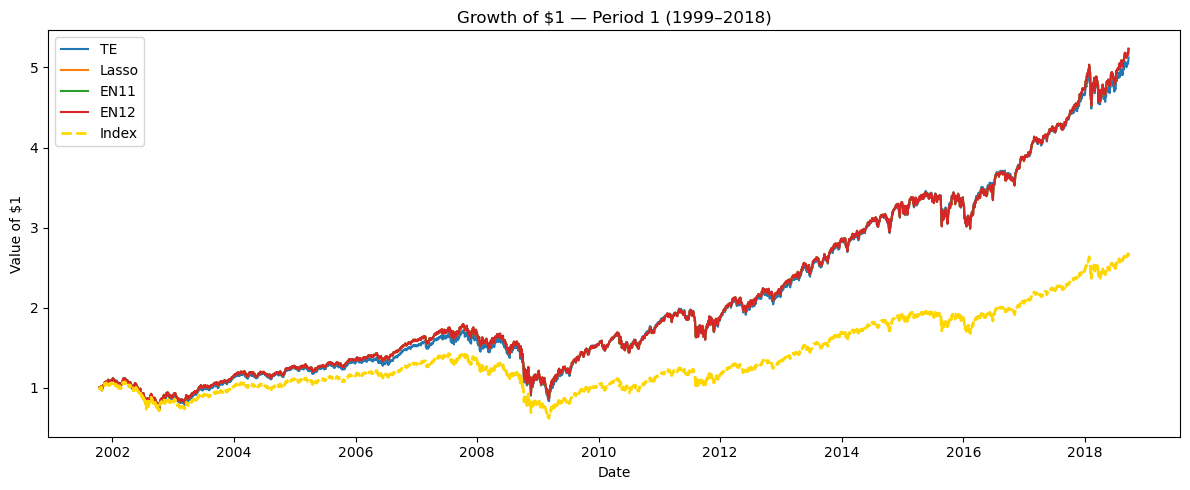

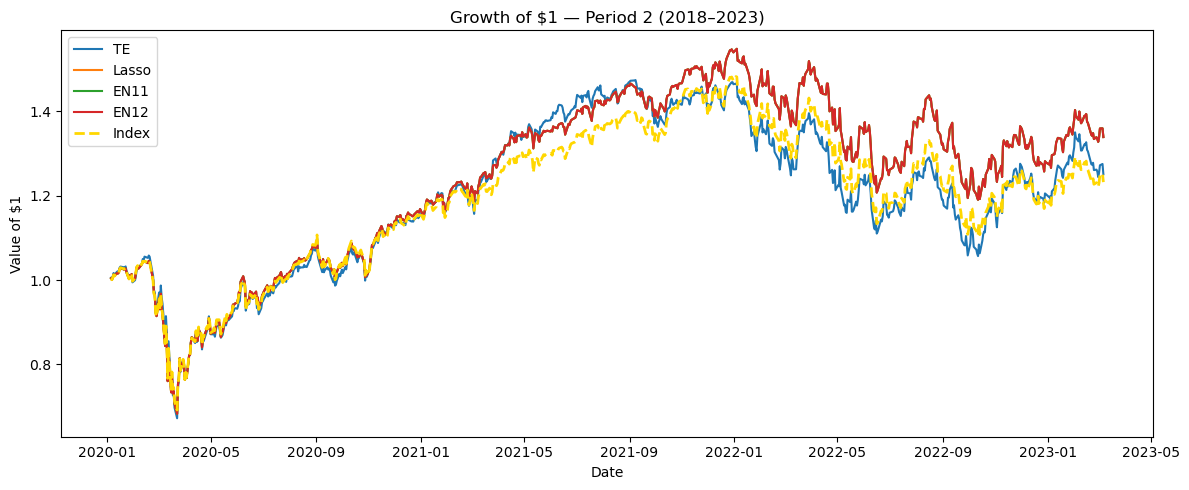

In [26]:
def plot_growth_of_1(results_all, title="Growth of $1"):
    plt.figure(figsize=(12, 5))
    for model, res in results_all.items():
        wealth = (1 + res['portfolio']).cumprod()
        plt.plot(wealth, label=model)
    #Plot index
    idx_wealth = (1 + list(results_all.values())[0]['index']).cumprod()
    plt.plot(idx_wealth, label="Index", color="gold", linewidth=2, linestyle="--")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value of $1")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_growth_of_1(results_p1_all, "Growth of $1 — Period 1 (1999–2018)")
plot_growth_of_1(results_p2_all, "Growth of $1 — Period 2 (2018–2023)")